# Arabesque: Country/Tradition Group Analysis (year <= 2011)

This notebook analyzes `Data/arabesque_531.csv` using the `countries` column.

Filtering rule: only rows with `year <= 2011` are included.

Countries are mapped into five groups:

- French: France, Belgium, Morocco/Belgium, Spain
- Russian_Vaganova: Russia, Ukraine, Lithuania
- British_RAD: United Kingdom, Australia, New Zealand, Portugal, South Africa, Cyprus, China (Hong Kong)
- Balanchine_American: USA
- Others: all remaining countries

The analysis measures six arabesque geometry angles and draws all figures directly with `matplotlib`.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_DIR = Path(r"D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main")
INPUT_CSV = PROJECT_DIR / "Data" / "arabesque_531.csv"
YEAR_LIMIT = 2011
OUTPUT_DIR = PROJECT_DIR / "country_group_arabesque_531_results_year_le_2010"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METRICS = [
    "arabesque_angle",
    "torso_tilt",
    "split_angle",
    "support_leg_plumb",
    "pelvic_tilt_angle",
    "shoulder_hip_torsion",
]

METRIC_LABELS = {
    "arabesque_angle": "Leg-torso angle",
    "torso_tilt": "Torso tilt",
    "split_angle": "Split angle",
    "support_leg_plumb": "Support-leg plumb",
    "pelvic_tilt_angle": "Pelvic tilt angle",
    "shoulder_hip_torsion": "Shoulder-hip torsion",
}

GROUP_ORDER = [
    "Russian_Vaganova",
    "French",
    "British_RAD",
    "Balanchine_American",
    "Others",
]

GROUP_COLORS = {
    "Russian_Vaganova": "#2f7d3b",
    "French": "#b33443",
    "British_RAD": "#7d56a0",
    "Balanchine_American": "#e1812c",
    "Others": "#8d8d8d",
}

COUNTRY_GROUPS = {
    "French": ["France", "Belgium", "Morocco/Belgium", "Spain"],
    "Russian_Vaganova": ["Russia", "Ukraine", "Lithuania"],
    "British_RAD": [
        "United Kingdom", "Australia", "New Zealand", "Portugal",
        "South Africa", "Cyprus", "China (Hong Kong)",
    ],
    "Balanchine_American": ["USA"],
}

COUNTRY_TO_GROUP = {
    country: group
    for group, countries in COUNTRY_GROUPS.items()
    for country in countries
}

print(INPUT_CSV)
print(OUTPUT_DIR)

D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main\Data\arabesque_531.csv
D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main\country_group_arabesque_531_results_year_le_2010


## 1. Load Data and Build Country Groups

In [9]:
raw = pd.read_csv(INPUT_CSV)
print(f"Original rows: {len(raw)}")

df = raw.copy()
df["countries_clean"] = df["countries"].astype("string").str.strip()
df["country_group"] = df["countries_clean"].map(COUNTRY_TO_GROUP).fillna("Others")
df["country_group"] = pd.Categorical(df["country_group"], GROUP_ORDER, ordered=True)

for col in METRICS + ["year", "decade"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=METRICS + ["country_group", "year"]).copy()
df = df[df["year"] <= YEAR_LIMIT].copy()
print(f"Rows with complete six-angle data and year <= {YEAR_LIMIT}: {len(df)}")

group_counts = df["country_group"].value_counts().reindex(GROUP_ORDER).fillna(0).astype(int)
display(group_counts.rename_axis("country_group").reset_index(name="n"))
display(df[["full_name", "year", "countries", "country_group", *METRICS]].head())

df.to_csv(OUTPUT_DIR / "filtered_country_group_rows.csv", index=False)

Original rows: 353
Rows with complete six-angle data and year <= 2011: 221


,country_group,n
0,Russian_Vaganova,13
1,French,49
2,British_RAD,21
3,Balanchine_American,16
4,Others,122


,full_name,year,countries,country_group,arabesque_angle,torso_tilt,split_angle,support_leg_plumb,pelvic_tilt_angle,shoulder_hip_torsion
0,Ch¨¦rittwizer Val¨¦rie,1982,France,French,103.998195,9.729439,83.998309,4.224310,17.013008,27.601310
1,Giannetti Maurizio,1982,Italy,Others,96.408662,22.787030,111.516435,6.256913,25.520135,25.116318
2,Guiderdoni Thierry,1982,France,French,94.572859,17.488438,102.988543,1.918503,19.763194,47.253121
3,Hall¨¦ Muriel,1982,France,French,98.423244,7.895892,81.713057,5.122012,15.530227,31.853461
4,Marache Sandrine,1982,France,French,93.751221,17.150790,101.634861,8.486631,25.293249,36.393644


## 2. Summary Tables

The compact table reports medians. The full summary table reports count, mean, median, standard deviation, and quartiles for each group and each angle.

In [10]:
def metric_summary(data: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    rows = []
    for group, sub in data.groupby("country_group", observed=True):
        for metric in metrics:
            values = sub[metric].dropna()
            rows.append({
                "country_group": group,
                "metric": metric,
                "label": METRIC_LABELS[metric],
                "n": int(values.count()),
                "mean": values.mean(),
                "std": values.std(ddof=1),
                "q1": values.quantile(0.25),
                "median": values.median(),
                "q3": values.quantile(0.75),
                "min": values.min(),
                "max": values.max(),
            })
    return pd.DataFrame(rows)

summary = metric_summary(df, METRICS)
summary.to_csv(OUTPUT_DIR / "country_group_six_angle_full_summary.csv", index=False)

median_table = summary.pivot_table(
    index="country_group",
    columns="label",
    values="median",
    aggfunc="first",
).reindex(GROUP_ORDER)

median_table = group_counts.rename("n").to_frame().join(median_table)
median_table.to_csv(OUTPUT_DIR / "country_group_six_angle_medians.csv")

display(median_table.round(2))
display(summary.round(3))

,n,Leg-torso angle,Pelvic tilt angle,Shoulder-hip torsion,Split angle,Support-leg plumb,Torso tilt
country_group,,,,,,,
Russian_Vaganova,13,81.99,18.87,30.49,109.48,5.63,14.85
French,49,99.63,20.39,30.27,95.96,6.81,16.86
British_RAD,21,93.53,18.61,22.34,93.84,7.06,15.22
Balanchine_American,16,95.19,19.70,28.79,104.09,7.68,15.84
Others,122,93.74,21.01,30.70,101.66,6.93,18.28


,country_group,metric,label,n,mean,std,q1,median,q3,min,max
0,Russian_Vaganova,arabesque_angle,Leg-torso angle,13,84.900,10.251,76.608,81.987,96.274,69.258,98.731
1,Russian_Vaganova,torso_tilt,Torso tilt,13,14.379,5.197,8.898,14.849,19.010,5.323,21.344
2,Russian_Vaganova,split_angle,Split angle,13,108.358,7.681,102.279,109.480,113.326,96.808,122.342
3,Russian_Vaganova,support_leg_plumb,Support-leg plumb,13,7.052,5.221,3.876,5.629,7.494,1.358,21.024
4,Russian_Vaganova,pelvic_tilt_angle,Pelvic tilt angle,13,18.943,7.351,14.379,18.869,21.989,4.627,35.372
5,Russian_Vaganova,shoulder_hip_torsion,Shoulder-hip torsion,13,32.998,12.722,25.064,30.493,39.312,13.362,62.538
6,French,arabesque_angle,Leg-torso angle,49,96.714,12.957,88.021,99.630,106.595,65.760,118.015
7,French,torso_tilt,Torso tilt,49,16.209,5.768,12.983,16.856,20.523,0.460,25.346
8,French,split_angle,Split angle,49,94.656,15.407,82.626,95.957,103.235,59.359,125.734
9,French,support_leg_plumb,Support-leg plumb,49,7.235,2.804,5.828,6.813,8.408,1.919,16.700


## 3. Boxplots for Six Angles

Each subplot compares the distribution of one angle across the five country/tradition groups. The line inside each box is the median; the box spans Q1-Q3.

C:\Users\lenovo\AppData\Local\Temp\ipykernel_23288\1471792983.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_23288\1471792983.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_23288\1471792983.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)
C:\Users\l

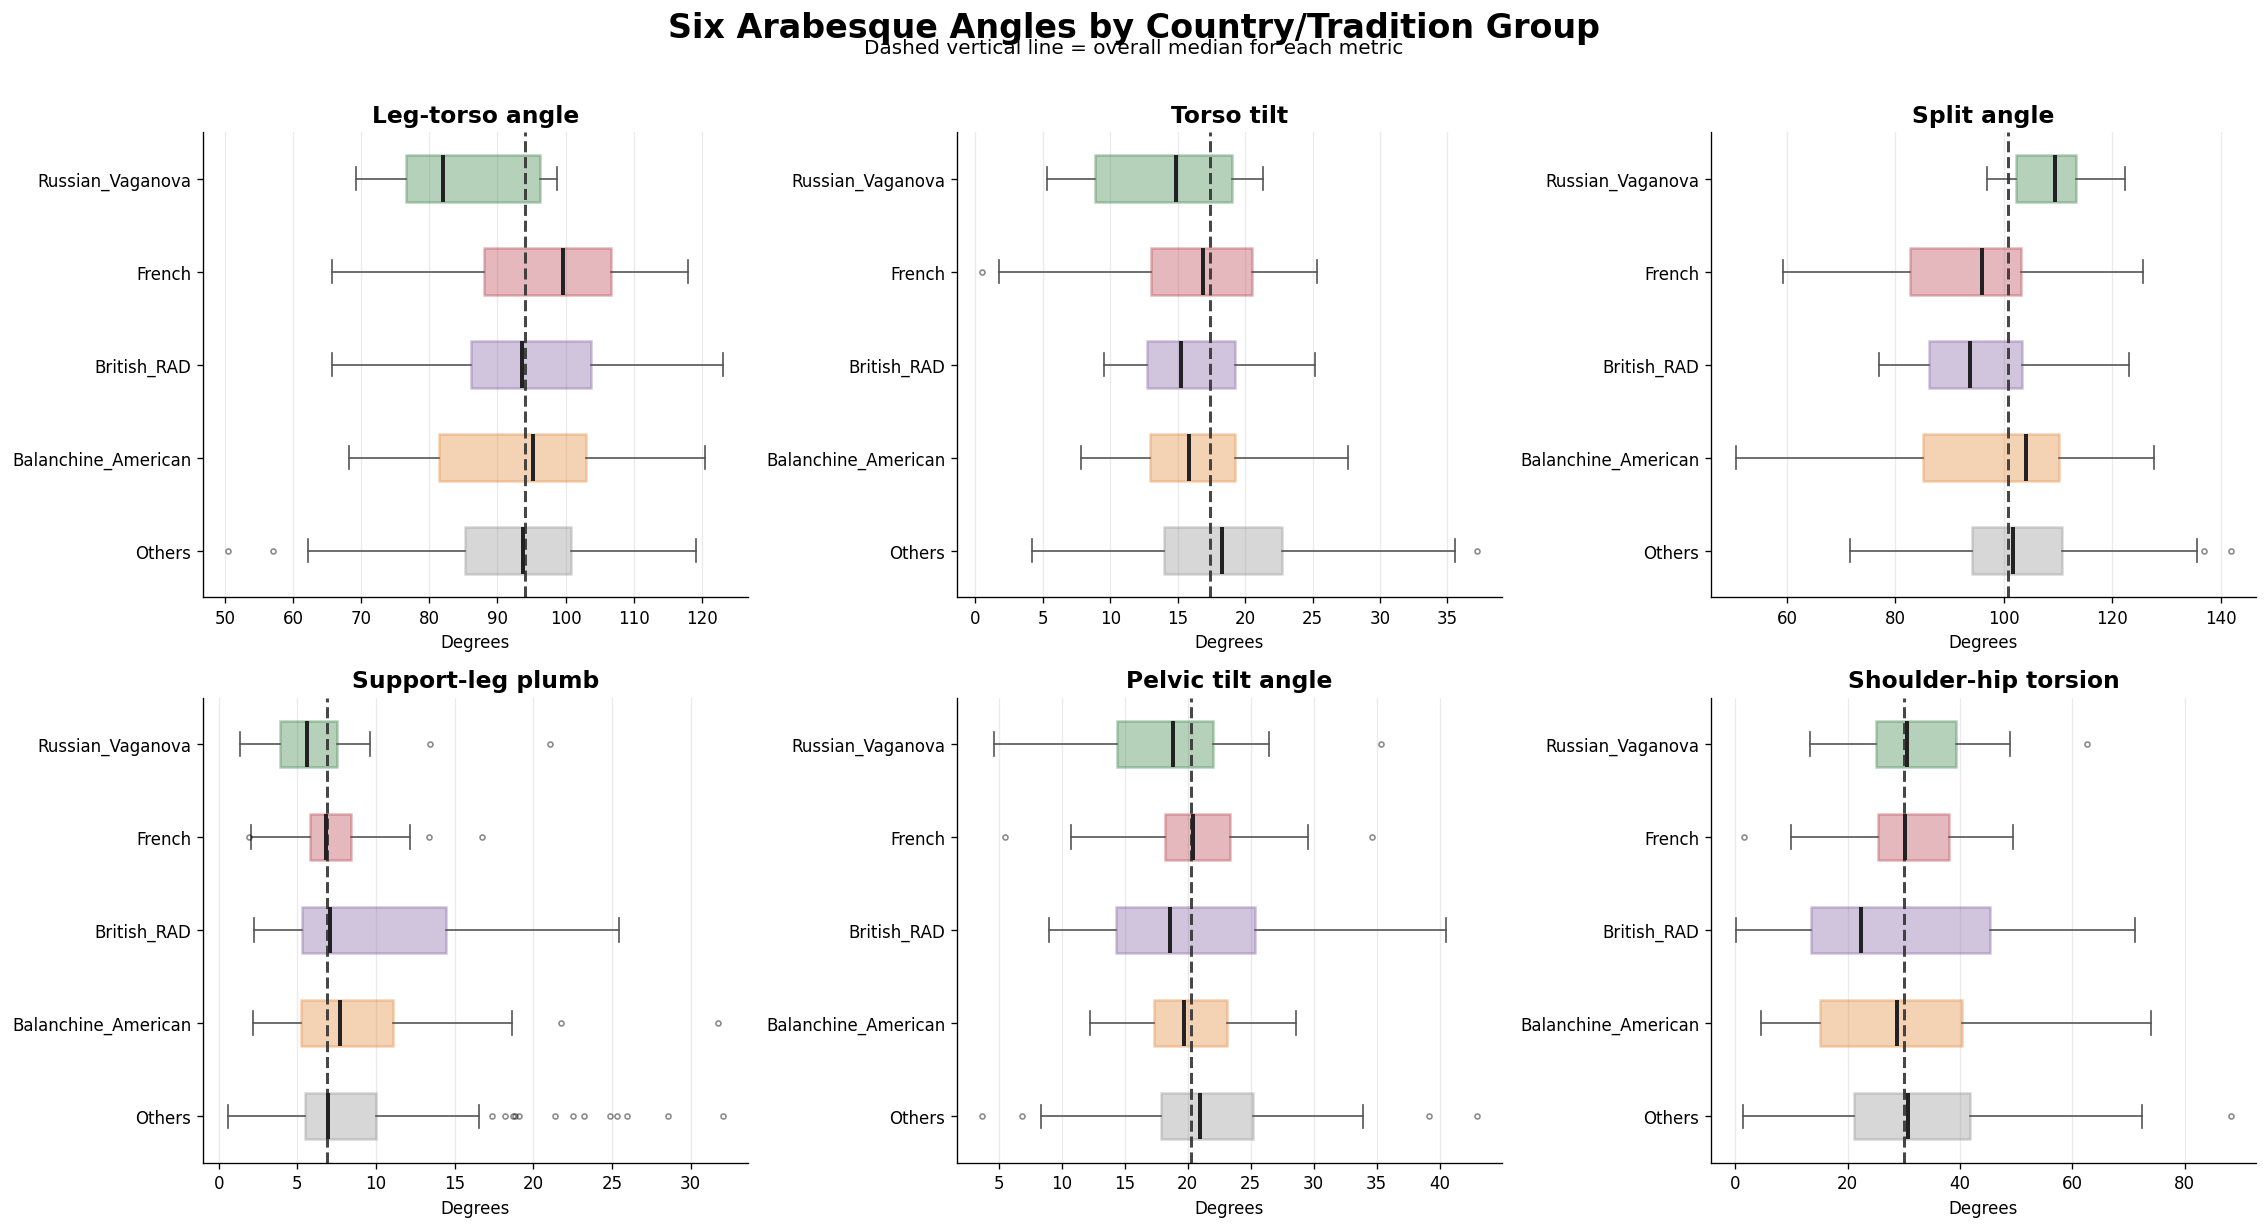

In [11]:
def plot_country_group_boxplots(data: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(19, 10))
    axes = axes.ravel()
    plot_order = list(reversed(GROUP_ORDER))

    for ax, metric in zip(axes, METRICS):
        values = [data.loc[data["country_group"] == group, metric].dropna().to_numpy() for group in plot_order]
        bp = ax.boxplot(values, vert=False, labels=plot_order, patch_artist=True, showfliers=True)

        for patch, group in zip(bp["boxes"], plot_order):
            patch.set_facecolor(GROUP_COLORS[group])
            patch.set_alpha(0.35)
            patch.set_edgecolor(GROUP_COLORS[group])
            patch.set_linewidth(1.5)

        for whisker in bp["whiskers"]:
            whisker.set_color("#555555")
        for cap in bp["caps"]:
            cap.set_color("#555555")
        for median in bp["medians"]:
            median.set_color("#222222")
            median.set_linewidth(2.4)
        for flier in bp["fliers"]:
            flier.set_marker("o")
            flier.set_markersize(3)
            flier.set_alpha(0.45)

        ax.axvline(data[metric].median(), color="#333333", linestyle="--", linewidth=1.8, alpha=0.9)
        ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight="bold")
        ax.set_xlabel("Degrees")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle("Six Arabesque Angles by Country/Tradition Group", fontsize=20, fontweight="bold", y=1.02)
    fig.text(0.5, 0.985, "Dashed vertical line = overall median for each metric", ha="center", fontsize=12)
    plt.tight_layout()
    return fig

fig = plot_country_group_boxplots(df)
fig.savefig(OUTPUT_DIR / "country_group_six_angle_boxplots.png", bbox_inches="tight")
plt.show()

## 4. Median + IQR Plot

This companion figure shows each group median as a dot and the interquartile range as a thick horizontal bar.

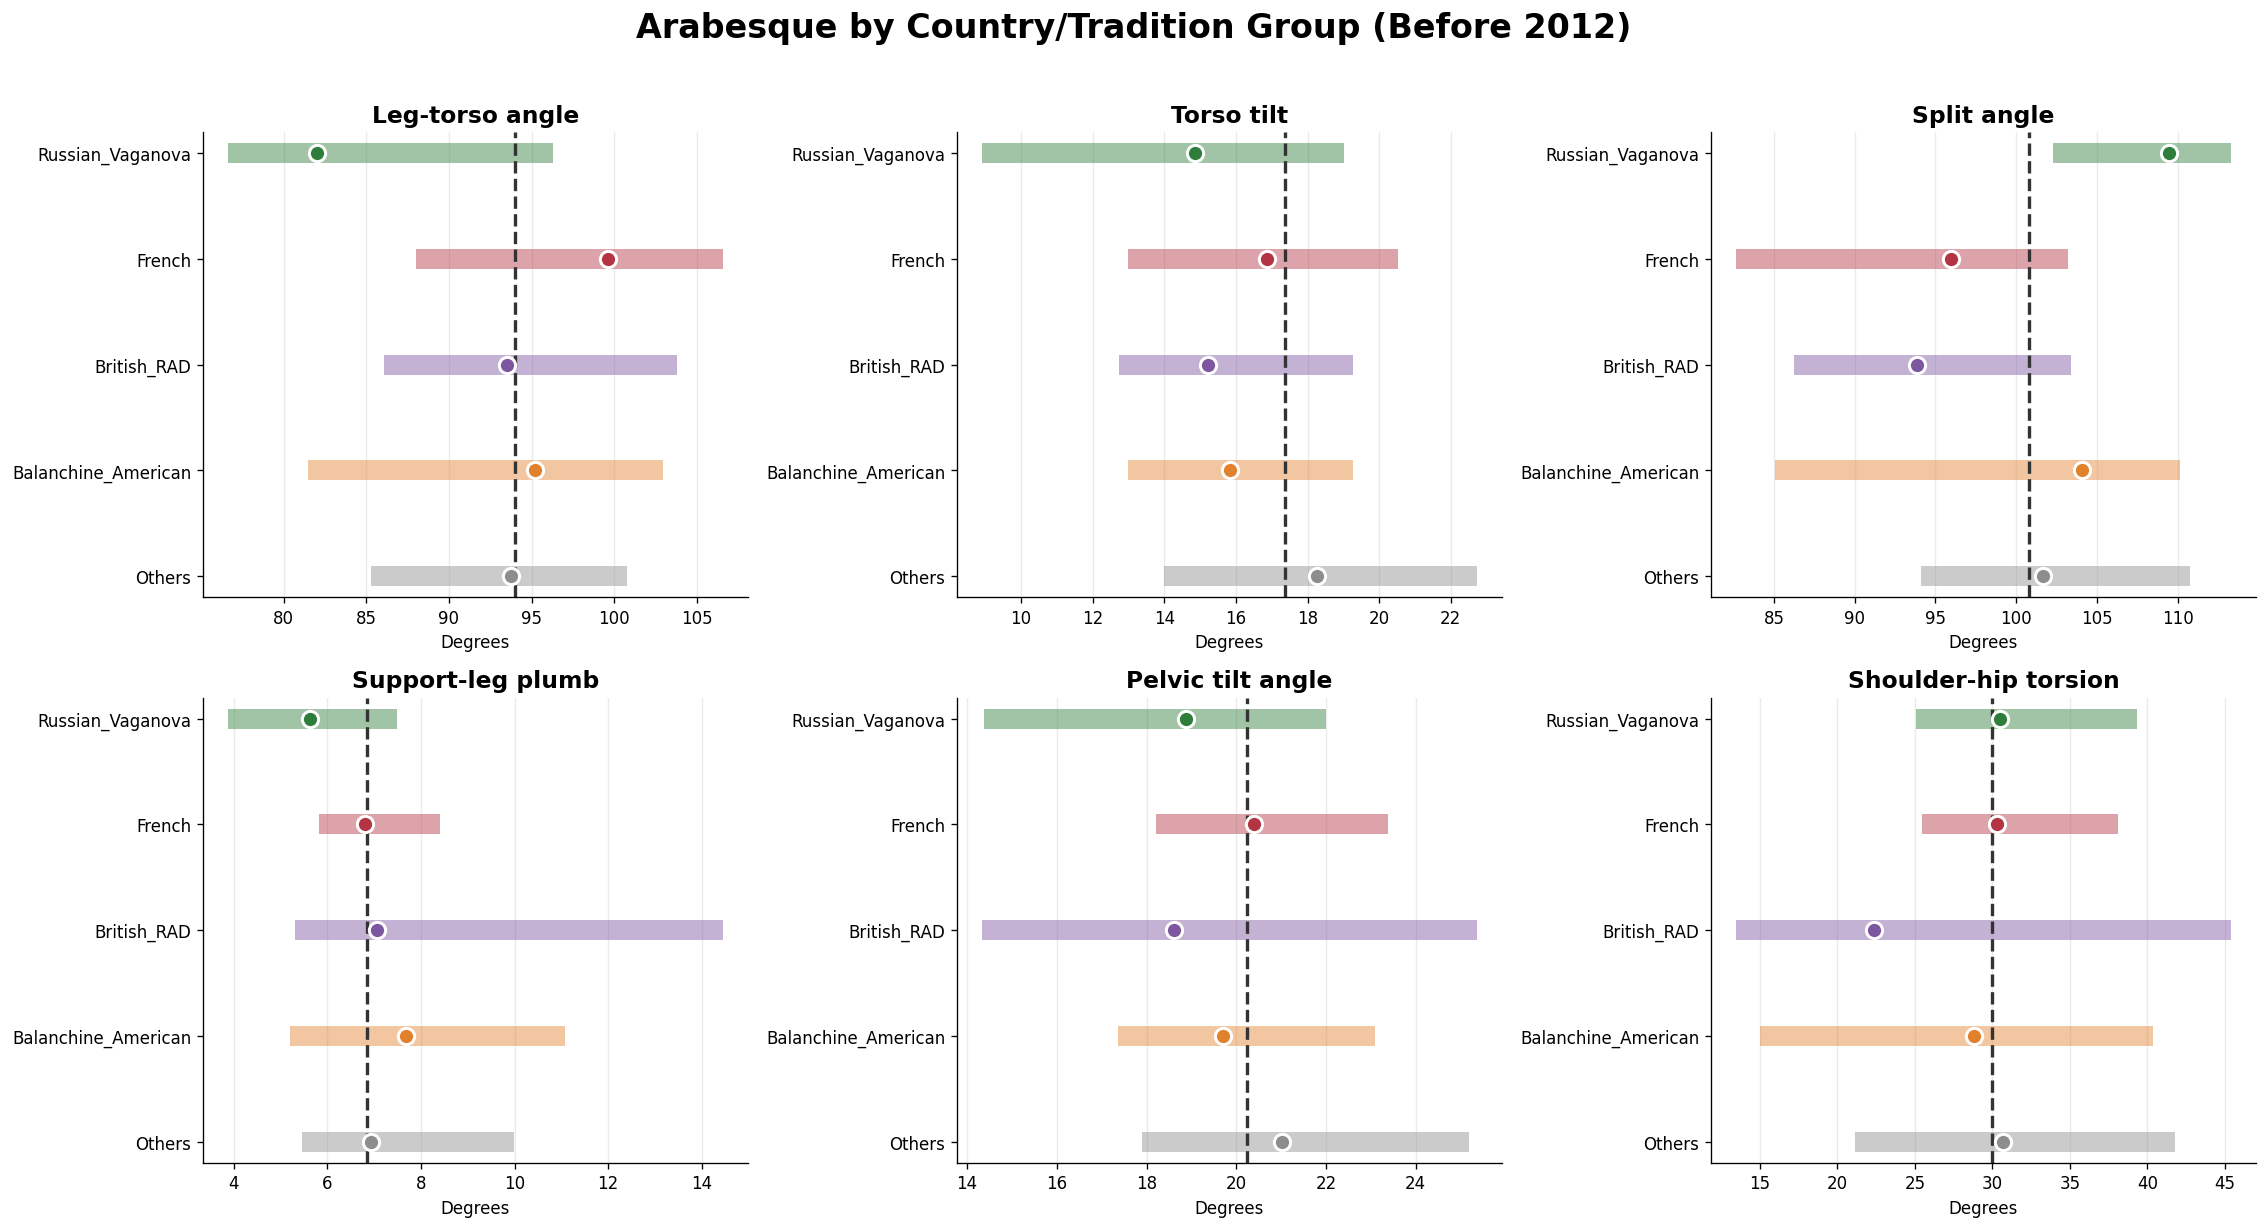

In [12]:
def plot_country_group_median_iqr(summary: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(19, 10))
    axes = axes.ravel()
    plot_order = list(reversed(GROUP_ORDER))

    for ax, metric in zip(axes, METRICS):
        sub = summary[summary["metric"] == metric].copy()
        sub["country_group"] = pd.Categorical(sub["country_group"], plot_order, ordered=True)
        sub = sub.sort_values("country_group")
        y = np.arange(len(sub))

        for pos, row in zip(y, sub.itertuples(index=False)):
            color = GROUP_COLORS[str(row.country_group)]
            ax.hlines(pos, row.q1, row.q3, color=color, linewidth=12, alpha=0.45)
            ax.scatter(row.median, pos, s=95, color=color, edgecolor="white", linewidth=1.8, zorder=3)

        ax.axvline(df[metric].median(), color="#333333", linestyle="--", linewidth=2.0)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["country_group"])
        ax.set_title(METRIC_LABELS[metric], fontsize=14, fontweight="bold")
        ax.set_xlabel("Degrees")
        ax.grid(axis="x", alpha=0.25)

    fig.suptitle("Arabesque by Country/Tradition Group (Before 2012)", fontsize=20, fontweight="bold", y=1.02)
    plt.tight_layout()
    return fig

fig = plot_country_group_median_iqr(summary)
fig.savefig(OUTPUT_DIR / "country_group_six_angle_median_iqr.png", bbox_inches="tight")
plt.show()

## 5. Final Files

In [6]:
print(f"All outputs are in: {OUTPUT_DIR}")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

All outputs are in: D:\EPFL 2025-2028\DH412 History and the digital\DH412 Final\DH412-History-and-the-Digital-main\country_group_arabesque_531_results_year_le_2010
- country_group_six_angle_boxplots.png
- country_group_six_angle_full_summary.csv
- country_group_six_angle_median_iqr.png
- country_group_six_angle_medians.csv
- filtered_country_group_rows.csv
